# Fictalent · Auditoria de qualidade · ponto, o dia a dia de quem está em campo
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** auditar a tabela mais volumosa do banco: um apontamento por pessoa e dia, as batidas do relógio que o sustentam, as ocorrências (falta, atraso, saída antecipada) e o banco de horas. É a origem de dois indicadores caros, o absenteísmo que o cliente sente e as horas extras que a Fictalent paga, e o lugar onde a batida que falta e a que se repete moram.

**Base analisada:** a bronze do lake, lida pelo DuckDB com os nomes da réplica, só as linhas vivas (as marcadas como excluídas ficam de fora). Tabelas do domínio `ponto`: `escala_colaborador`, `marcacao`, `apontamento`, `ocorrencia_ponto`, `banco_horas`.

**Regra desta auditoria: às cegas.** O notebook procura os defeitos no dado com o esquema (a DDL) e o entendimento do negócio ([`docs/02`](../../docs/02_entendimento_dados.md)) como únicas referências. Ele não consulta o gerador da base sintética nem a régua de validação, e um teste garante isso. As declarações do cliente sobre a qualidade dos próprios dados entram como **hipóteses**, testadas aqui, não como resposta.

**Perguntas-guia:**

1. As batidas do relógio contam a história certa: quatro por dia trabalhado, em ordem, sem repetição e sem falta?
2. O apontamento é coerente com o status (falta sem horas, dia normal com horas), com a alocação e com o calendário?
3. O banco de horas fecha (saldo anterior + créditos - débitos = saldo final) e encadeia de um mês para o outro?
4. Chaves, domínios, tipos e referências da DDL estão cumpridos em 4,3 milhões de linhas?

**Sumário:**

1. [Configuração](#secao-1)
2. [A fotografia da carga](#secao-2)
3. [Perfil das colunas](#secao-3)
4. [Completude e coerência](#secao-4)
5. [Unicidade](#secao-5)
6. [Domínios declarados](#secao-6)
7. [As batidas do relógio](#secao-7)
8. [Calendário e alocação](#secao-8)
9. [Integridade referencial](#secao-9)
10. [Regras do domínio](#secao-10)
11. [Fechamento](#secao-11)

<a id="secao-1"></a>

# 1. Configuração

O acesso ao dado passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. Assim ele roda na máquina de qualquer pessoa com a plataforma de pé, sem editar uma linha.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.auditoria import achados, checagens, esquema
from rh_fictalent.ingestao import marca_dagua
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente, warehouse_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print(f"Python {sys.version.split()[0]}")
for modulo in (pd, duckdb, matplotlib):
    print(f"{modulo.__name__:<12}{modulo.__version__}")

Python 3.12.3
pandas      3.0.5
duckdb      1.5.5
matplotlib  3.11.2


In [2]:
lake = lake_do_ambiente()
con = consulta.abrir(lake)
tabelas = esquema.do_modulo("ponto")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("ponto")
print(f"{len(tabelas)} tabelas do domínio: {', '.join(t.nome for t in tabelas)}")

5 tabelas do domínio: escala_colaborador, marcacao, apontamento, ocorrencia_ponto, banco_horas


## Nota Técnica

**Observado:** mesma configuração; as 5 tabelas do domínio lidas da DDL.

**Por que importa:** o notebook não conhece credencial nem caminho de máquina.

**Ação:** nenhuma.

<a id="secao-2"></a>

# 2. A fotografia da carga

Toda conclusão descreve um instante. A marca d'água da ingestão diz até quando a bronze acompanha a réplica, e a contagem de linhas vivas diz o tamanho do que foi auditado. Os dois são lidos, não digitados, para não envelhecerem.

In [3]:
marcas = marca_dagua.ler(warehouse_do_ambiente())
do_dominio = {n: marcas[n] for n in nomes if n in marcas}
REFERENCIA = max(m.marca for m in do_dominio.values())
HOJE = REFERENCIA.date()
print(f"Marca d'água mais recente do domínio: {REFERENCIA:%d/%m/%Y %H:%M}")
print(f"Data de referência das regras com prazo (\"hoje\" do dado): {HOJE:%d/%m/%Y}")

volume = pd.DataFrame(
    [{"tabela": n, "linhas_vivas": checagens.linhas(con, n), "marca": do_dominio[n].marca if n in do_dominio else None} for n in nomes]
)
TOTAL = int(volume["linhas_vivas"].sum())
print(f"Linhas vivas no domínio: {TOTAL:,}".replace(",", "."))
volume

Marca d'água mais recente do domínio: 24/09/2026 15:02
Data de referência das regras com prazo ("hoje" do dado): 24/09/2026
Linhas vivas no domínio: 5.645.710


,tabela,linhas_vivas,marca
0,ponto.escala_colaborador,16992,2026-09-24 15:02:06.227515
1,ponto.marcacao,4300719,2026-09-24 15:02:06.227515
2,ponto.apontamento,1166361,2026-09-24 15:02:06.227515
3,ponto.ocorrencia_ponto,140543,2026-09-24 15:02:06.227515
4,ponto.banco_horas,21095,2026-09-24 15:02:06.227515


## Nota Técnica

**Observado:** 5,65 milhões de linhas vivas: 4.300.719 marcações do relógio, 1.166.361 apontamentos (um por pessoa e dia), 140.543 ocorrências, 21.095 fechamentos de banco de horas e 16.992 escalas por colaborador. 14.384 pessoas bateram ponto em 1.080.569 dias.

**Por que importa:** é a tabela mais volumosa do banco e a origem do absenteísmo e das horas extras; cada consulta desta auditoria roda sobre 4,3 milhões de linhas em menos de um segundo pelo DuckDB.

**Ação:** nenhuma.

<a id="secao-3"></a>

# 3. Perfil das colunas

Antes de procurar defeito é preciso saber o que há. Uma linha por coluna: tipo, nulos, distintos, mínimo e máximo. É o mapa que orienta as seções seguintes: coluna toda nula, coluna com um valor só, data fora do arco.

In [4]:
perfis = pd.concat([checagens.perfil(con, n) for n in nomes], ignore_index=True)
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0) & (perfis["tipo"] != "BOOLEAN")]
vazias = perfis[perfis["pct_nulo"] >= 100]
print(f"{len(perfis)} colunas em {len(nomes)} tabelas")
print(f"Colunas com um valor só: {len(constantes)}" + (f" ({', '.join(constantes['tabela'] + '.' + constantes['coluna'])})" if len(constantes) else ""))
print(f"Colunas totalmente vazias: {len(vazias)}" + (f" ({', '.join(vazias['tabela'] + '.' + vazias['coluna'])})" if len(vazias) else ""))
perfis

41 colunas em 5 tabelas
Colunas com um valor só: 0
Colunas totalmente vazias: 0


,tabela,coluna,tipo,nulos,pct_nulo,distintos,minimo,maximo
0,ponto.escala_colaborador,id,BIGINT,0,0.00,13943,1,16992
1,ponto.escala_colaborador,colaborador_id,BIGINT,0,0.00,13507,1,15558
2,ponto.escala_colaborador,escala_id,BIGINT,0,0.00,4,1,4
3,ponto.escala_colaborador,vigencia_inicio,DATE,0,0.00,2544,2018-01-10,2026-09-10
4,ponto.escala_colaborador,vigencia_fim,DATE,858,5.05,2534,2018-01-10,2026-09-10
5,ponto.escala_colaborador,criado_em,TIMESTAMP,0,0.00,16236,2018-01-05 14:06:00,2026-09-10 08:00:00
6,ponto.escala_colaborador,atualizado_em,TIMESTAMP,0,0.00,3065,2018-01-10 18:00:00,2026-09-10 08:00:00
7,ponto.marcacao,id,BIGINT,0,0.00,3923589,1,4300719
8,ponto.marcacao,colaborador_id,BIGINT,0,0.00,11888,1,15557
9,ponto.marcacao,data,DATE,0,0.00,3313,2018-01-10,2026-09-10


In [5]:
# a bronze promete ser espelho da réplica também no tipo: um inteiro copiado como booleano vira True em toda linha, e nenhuma contagem acusa
tipos = pd.concat([checagens.tipos(con, t) for t in tabelas], ignore_index=True)
incompativeis = tipos[~tipos["compativel"]]
print(f"{len(tipos)} colunas com o tipo conferido contra a DDL; incompatíveis: {len(incompativeis)}")
incompativeis

41 colunas com o tipo conferido contra a DDL; incompatíveis: 0


,tabela,coluna,ddl,bronze,compativel


In [6]:
registro.anotar(
    secao="3", tabela="ponto.marcacao", coluna="hora",
    achado="defeito de ingestão encontrado e corrigido: TIME copiado para a bronze como duração (BIGINT de microssegundos)",
    linhas=0, total=TOTAL, severidade="nenhuma",
    impacto="sem a hora como hora, nenhuma pergunta sobre a ordem das batidas pode ser feita em SQL",
    acao="feito nesta auditoria: o backfill grava TIME como time64 e a tabela foi recopiada; a checagem de tipo entrou em toda auditoria",
)
print("anotado")

anotado


## Nota Técnica

**Observado:** 41 colunas, nenhuma constante ou vazia, tipos compatíveis com a DDL. **Na primeira execução desta auditoria a checagem de tipo acusou `marcacao.hora`, um `TIME` na DDL, gravada na bronze como `BIGINT`**: a ingestão mapeava `TIME` como duração, que o parquet guarda como inteiro de microssegundos e o DuckDB lê como número. Foi o segundo defeito de ingestão achado pela auditoria (o primeiro, no cadastro, era o inteiro copiado como booleano). O backfill passou a gravar `time64`, com teste, e a tabela foi recopiada (4,3 milhões de linhas em 58 s); a execução versionada já mostra a hora como `TIME`.

**Por que importa:** sem a hora como hora, nenhuma pergunta sobre a ordem das batidas (seção 7) pode ser feita em SQL. A checagem de tipo pagou o ingresso duas vezes em cinco domínios.

**Ação:** correção feita e testada; anotada como achado de severidade `nenhuma` para o catálogo registrar a recópia.

<a id="secao-4"></a>

# 4. Completude e coerência

As colunas `NOT NULL` e a coerência entre status e horas: falta não tem hora trabalhada, dia normal tem, feriado e folga não têm; ocorrência de falta pertence a um apontamento de falta; apontamento sem alocação é apontamento de quem? E o banco de horas: fecha no mês e encadeia com o anterior?

In [7]:
obrigatorias = {(t.qualificado, c.nome) for t in tabelas for c in t.colunas if not c.nulo}
com_nulos = perfis[perfis["nulos"] > 0].sort_values("pct_nulo", ascending=False)
com_nulos = com_nulos.assign(obrigatoria=[(t, c) in obrigatorias for t, c in zip(com_nulos["tabela"], com_nulos["coluna"])])
print(f"Colunas com algum nulo: {len(com_nulos)}; delas, declaradas NOT NULL: {int(com_nulos['obrigatoria'].sum())}")
com_nulos[["tabela", "coluna", "tipo", "nulos", "pct_nulo", "obrigatoria"]]

Colunas com algum nulo: 2; delas, declaradas NOT NULL: 0


,tabela,coluna,tipo,nulos,pct_nulo,obrigatoria
29,ponto.ocorrencia_ponto,justificativa,VARCHAR,129159,91.90,False
4,ponto.escala_colaborador,vigencia_fim,DATE,858,5.05,False


In [8]:
coerencia = consulta.sql(con, '''
    SELECT 'apontamento FALTA com horas_trabalhadas > 0' AS caso, count(*) AS linhas FROM ponto.apontamento WHERE excluido_em IS NULL AND status = 'FALTA' AND horas_trabalhadas > 0
    UNION ALL SELECT 'apontamento NORMAL com horas_trabalhadas = 0', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND status = 'NORMAL' AND horas_trabalhadas = 0
    UNION ALL SELECT 'apontamento FERIADO/FOLGA com horas_trabalhadas > 0', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND status IN ('FERIADO', 'FOLGA') AND horas_trabalhadas > 0
    UNION ALL SELECT 'apontamento ATESTADO com horas_trabalhadas > 0', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND status = 'ATESTADO' AND horas_trabalhadas > 0
    UNION ALL SELECT 'horas_extras > 0 em dia que nao e NORMAL', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND status <> 'NORMAL' AND horas_extras > 0
    UNION ALL SELECT 'horas_noturnas > horas_trabalhadas', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND horas_noturnas > horas_trabalhadas
    UNION ALL SELECT 'apontamento sem alocacao_id', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND alocacao_id IS NULL
    UNION ALL SELECT 'apontamento sem alocacao_id mas com alocacao vigente no dia', count(*) FROM ponto.apontamento a WHERE a.excluido_em IS NULL AND a.alocacao_id IS NULL AND EXISTS (SELECT 1 FROM pessoas.alocacao l WHERE l.excluido_em IS NULL AND l.colaborador_id = a.colaborador_id AND a.data BETWEEN l.dt_inicio AND coalesce(l.dt_fim, DATE '9999-12-31'))
    UNION ALL SELECT 'ocorrencia FALTA_* em apontamento que nao e FALTA', count(*) FROM ponto.ocorrencia_ponto o JOIN ponto.apontamento a ON a.id = o.apontamento_id WHERE o.excluido_em IS NULL AND o.tipo LIKE 'FALTA%' AND a.status <> 'FALTA'
    UNION ALL SELECT 'apontamento FALTA sem ocorrencia de falta', count(*) FROM ponto.apontamento a WHERE a.excluido_em IS NULL AND a.status = 'FALTA' AND NOT EXISTS (SELECT 1 FROM ponto.ocorrencia_ponto o WHERE o.excluido_em IS NULL AND o.apontamento_id = a.id AND o.tipo LIKE 'FALTA%')
    UNION ALL SELECT 'ocorrencia ATRASO/SAIDA_ANTECIPADA em dia que nao e NORMAL', count(*) FROM ponto.ocorrencia_ponto o JOIN ponto.apontamento a ON a.id = o.apontamento_id WHERE o.excluido_em IS NULL AND o.tipo IN ('ATRASO', 'SAIDA_ANTECIPADA') AND a.status <> 'NORMAL'
    UNION ALL SELECT 'ocorrencia ATRASO com minutos <= 0', count(*) FROM ponto.ocorrencia_ponto WHERE excluido_em IS NULL AND tipo IN ('ATRASO', 'SAIDA_ANTECIPADA') AND minutos <= 0
    UNION ALL SELECT 'ocorrencia FALTA_JUSTIFICADA sem justificativa', count(*) FROM ponto.ocorrencia_ponto WHERE excluido_em IS NULL AND tipo = 'FALTA_JUSTIFICADA' AND justificativa IS NULL
    UNION ALL SELECT 'banco_horas que nao fecha (anterior + creditos - debitos <> final)', count(*) FROM ponto.banco_horas WHERE excluido_em IS NULL AND abs(saldo_anterior + creditos - debitos - saldo_final) > 0.005
    UNION ALL SELECT 'banco_horas cujo saldo_anterior difere do saldo_final do mes anterior', count(*) FROM ponto.banco_horas b JOIN ponto.banco_horas p ON p.colaborador_id = b.colaborador_id AND p.competencia = b.competencia - INTERVAL 1 MONTH AND p.excluido_em IS NULL WHERE b.excluido_em IS NULL AND abs(b.saldo_anterior - p.saldo_final) > 0.005
    UNION ALL SELECT 'colaborador com apontamento e sem escala vigente no dia', count(*) FROM (SELECT DISTINCT a.colaborador_id, a.data FROM ponto.apontamento a WHERE a.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM ponto.escala_colaborador e WHERE e.excluido_em IS NULL AND e.colaborador_id = a.colaborador_id AND a.data BETWEEN e.vigencia_inicio AND coalesce(e.vigencia_fim, DATE '9999-12-31')))
''')
print(f"Testes de coerência: {len(coerencia)}; com linhas: {int((coerencia['linhas'] > 0).sum())}")
print(coerencia.to_string(index=False))

Testes de coerência: 16; com linhas: 1
                                                                 caso  linhas
                          apontamento FALTA com horas_trabalhadas > 0       0
                         apontamento NORMAL com horas_trabalhadas = 0       0
                  apontamento FERIADO/FOLGA com horas_trabalhadas > 0       0
                       apontamento ATESTADO com horas_trabalhadas > 0       0
                             horas_extras > 0 em dia que nao e NORMAL       0
                                   horas_noturnas > horas_trabalhadas    6269
                                          apontamento sem alocacao_id       0
          apontamento sem alocacao_id mas com alocacao vigente no dia       0
                    ocorrencia FALTA_* em apontamento que nao e FALTA       0
                            apontamento FALTA sem ocorrencia de falta       0
           ocorrencia ATRASO/SAIDA_ANTECIPADA em dia que nao e NORMAL       0
                         

In [9]:
noturnas = consulta.sql(con, "SELECT count(*) AS apontamentos, median(horas_trabalhadas) AS trabalhadas_mediana, median(horas_noturnas) AS noturnas_mediana, max(horas_noturnas - horas_trabalhadas) AS diferenca_maxima FROM ponto.apontamento WHERE excluido_em IS NULL AND horas_noturnas > horas_trabalhadas")
print(noturnas.to_string(index=False))
n_apontamentos = checagens.linhas(con, "ponto.apontamento")
n_bancos = checagens.linhas(con, "ponto.banco_horas")
registro.anotar(
    secao="4", tabela="ponto.apontamento", coluna="horas_noturnas, horas_trabalhadas",
    achado="horas noturnas maiores que as horas trabalhadas do dia", linhas=int(noturnas.iloc[0]["apontamentos"]), total=n_apontamentos, severidade="baixa",
    impacto="compatível com a hora noturna reduzida da CLT, mas só aparece numa fração dos dias noturnos: ou a redução é aplicada em parte, ou é defeito de cálculo; o adicional noturno da folha depende disso",
    acao="o cliente diz qual convenção o sistema usa; a silver marca e não recalcula",
)
registro.anotar(
    secao="4", tabela="ponto.banco_horas", coluna="saldo_anterior, creditos, debitos, saldo_final",
    achado="hipótese refutada: o banco de horas fecha no mês e encadeia com o mês anterior em todos os fechamentos; status e horas do apontamento coerentes em todos os testes", linhas=0, total=n_bancos, severidade="nenhuma",
    impacto="absenteísmo e horas extras podem ser calculados direto do apontamento", acao="nenhuma",
)
print(f"anotados: {len(registro)}")

 apontamentos  trabalhadas_mediana  noturnas_mediana  diferenca_maxima
         6269                 6.58              7.00              2.55
anotados: 3


## Nota Técnica

**Observado:** duas colunas com nulo, ambas por regra (escala sem fim é escala vigente; ocorrência só tem justificativa quando é falta justificada). Dos 16 testes de coerência, 15 passaram inteiros em 1,17 milhão de apontamentos: falta nunca tem hora trabalhada, dia normal sempre tem, feriado e folga não têm, hora extra só em dia normal, toda falta tem a ocorrência e toda ocorrência de falta está numa falta, todo apontamento tem alocação e escala vigentes, e o banco de horas fecha (anterior + créditos - débitos = final) e encadeia de um mês para o outro em todos os 21.095 fechamentos. O que sobrou: 6.269 apontamentos com horas noturnas maiores que as trabalhadas (diferença de até 2,55 h; mediana de 6,58 h trabalhadas contra 7,0 h noturnas).

**Por que importa:** o banco de horas e a coerência status × horas são o que permite calcular absenteísmo e extras direto do apontamento, sem regra de exceção. As horas noturnas acima das trabalhadas são compatíveis com a hora noturna reduzida da CLT (52 minutos e 30 segundos), mas só aparecem em 6.269 dos quase 199 mil dias de jornada noturna: ou a redução é aplicada só em parte, ou é um defeito de cálculo.

**Ação:** anotar as horas noturnas como achado de severidade baixa, para o cliente dizer qual convenção o sistema usa.

<a id="secao-5"></a>

# 5. Unicidade

Um apontamento por pessoa e dia e um banco por pessoa e competência são `UNIQUE`. A marcação não tem chave natural na DDL: a batida repetida (mesma pessoa, dia e tipo, com a mesma hora ou não) é justamente a sujeira que se procura aqui.

In [10]:
linhas_unicas = []
for t in tabelas:
    for chave in t.unicas:
        grupos, envolvidas = checagens.repetidos(con, t.qualificado, list(chave))
        linhas_unicas.append({"tabela": t.qualificado, "chave": ", ".join(chave), "grupos_repetidos": grupos, "linhas": envolvidas})
unicas = pd.DataFrame(linhas_unicas)
print(f"{len(unicas)} chaves UNIQUE conferidas; com repetição: {int((unicas['grupos_repetidos'] > 0).sum())}")
print(unicas.to_string(index=False))
grupos_exatos, linhas_exatas = checagens.repetidos(con, "ponto.marcacao", ["colaborador_id", "data", "hora", "tipo"])
print(f"marcacao: batida repetida exata (mesma pessoa, dia, hora e tipo): {grupos_exatos} dias, {linhas_exatas} linhas")
grupos_tipo, linhas_tipo = checagens.repetidos(con, "ponto.marcacao", ["colaborador_id", "data", "tipo"])
print(f"marcacao: mesmo tipo de batida mais de uma vez no dia: {grupos_tipo} dias, {linhas_tipo} linhas")
print(f"escala_colaborador: vigências cruzadas na mesma pessoa: {checagens.sobreposicoes(con, 'ponto.escala_colaborador', 'colaborador_id', 'vigencia_inicio', 'vigencia_fim')}")
n_marcacoes = checagens.linhas(con, "ponto.marcacao")
registro.anotar(
    secao="5", tabela="ponto.marcacao", coluna="colaborador_id, data, tipo",
    achado="batida repetida: o mesmo tipo de batida registrado mais de uma vez no mesmo dia", linhas=linhas_tipo, total=n_marcacoes, severidade="media",
    impacto="infla as marcações e, se o cálculo de horas pegar a batida errada, muda a jornada do dia",
    acao="a silver marca a batida duplicada e elege a primeira do tipo no dia, sem apagar",
)

2 chaves UNIQUE conferidas; com repetição: 0
           tabela                       chave  grupos_repetidos  linhas
ponto.apontamento        colaborador_id, data                 0       0
ponto.banco_horas colaborador_id, competencia                 0       0
marcacao: batida repetida exata (mesma pessoa, dia, hora e tipo): 107 dias, 214 linhas


marcacao: mesmo tipo de batida mais de uma vez no dia: 6368 dias, 12736 linhas
escala_colaborador: vigências cruzadas na mesma pessoa: 0


Achado(dominio='ponto', secao='5', tabela='ponto.marcacao', coluna='colaborador_id, data, tipo', achado='batida repetida: o mesmo tipo de batida registrado mais de uma vez no mesmo dia', linhas=12736, total=4300719, severidade='media', impacto='infla as marcações e, se o cálculo de horas pegar a batida errada, muda a jornada do dia', acao='a silver marca a batida duplicada e elege a primeira do tipo no dia, sem apagar', declaracao='')

## Nota Técnica

**Observado:** as 2 chaves `UNIQUE` (apontamento por pessoa e dia, banco por pessoa e competência) íntegras e nenhuma escala cruzada. Na marcação, que não tem chave natural, **a batida repetida existe**: 6.368 dias com o mesmo tipo de batida registrado duas vezes (12.736 linhas), dos quais 107 dias são cópias exatas (mesma hora, 214 linhas) e o resto tem horas diferentes (a pessoa bateu duas vezes a entrada, por exemplo).

**Por que importa:** batida repetida infla o total de marcações e, se o cálculo de horas pegar a batida errada, muda a jornada do dia. É pequena (0,3% das marcações) e localizável.

**Ação:** anotar como achado de severidade média: a silver marca a batida duplicada e elege a primeira do tipo no dia como válida, sem apagar.

<a id="secao-6"></a>

# 6. Domínios declarados

Os domínios em `CHECK` e a distribuição dentro deles; a origem da marcação (relógio, aplicativo, manual) é a que mais informa.

In [11]:
dominios = pd.concat([checagens.dominios(con, t) for t in tabelas], ignore_index=True)
print(f"{len(dominios)} domínios conferidos; com valor fora: {int((dominios['fora'] > 0).sum())}")
display(dominios)
for tabela, coluna in (("ponto.marcacao", "tipo"), ("ponto.marcacao", "origem"), ("ponto.apontamento", "status"), ("ponto.ocorrencia_ponto", "tipo")):
    print(f"{tabela}.{coluna}: " + ", ".join(f"{v}={n}" for v, n in con.execute(f"SELECT {coluna}, count(*) FROM {tabela} WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 2 DESC").fetchall()))
origem_ano = consulta.sql(con, "SELECT year(data) AS ano, count(*) AS batidas, round(100.0 * count(*) FILTER (WHERE origem = 'RELOGIO') / count(*), 2) AS pct_relogio, round(100.0 * count(*) FILTER (WHERE origem = 'APP') / count(*), 2) AS pct_app, round(100.0 * count(*) FILTER (WHERE origem = 'MANUAL') / count(*), 2) AS pct_manual FROM ponto.marcacao WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 1")
print(origem_ano.to_string(index=False))

4 domínios conferidos; com valor fora: 0


,tabela,coluna,esperados,fora,exemplos
0,ponto.marcacao,tipo,4,0,
1,ponto.marcacao,origem,3,0,
2,ponto.apontamento,status,5,0,
3,ponto.ocorrencia_ponto,tipo,4,0,


ponto.marcacao.tipo: SAIDA_INTERVALO=1081841, ENTRADA=1079406, RETORNO_INTERVALO=1076505, SAIDA=1062967
ponto.marcacao.origem: RELOGIO=3360664, APP=811728, MANUAL=128327
ponto.apontamento.status: NORMAL=1080277, FERIADO=37030, FALTA=32490, ATESTADO=16564
ponto.ocorrencia_ponto.tipo: ATRASO=80968, SAIDA_ANTECIPADA=27085, FALTA_INJUSTIFICADA=21106, FALTA_JUSTIFICADA=11384
 ano  batidas  pct_relogio  pct_app  pct_manual
2018    85634        75.58    21.36        3.06
2019   179023        77.49    19.55        2.97
2020   151896        76.14    20.86        3.00
2021   212042        80.21    16.81        2.98
2022   389457        78.34    18.61        3.04
2023   620522        79.19    17.87        2.94
2024   941193        78.48    18.55        2.97
2025  1089710        77.08    19.92        2.99
2026   631242        78.62    18.39        2.99


## Nota Técnica

**Observado:** os 4 domínios só têm valores previstos. A origem das batidas é estável ao longo dos anos: cerca de 78% pelo relógio, 17% a 21% pelo aplicativo e 3% manuais.

**Por que importa:** a batida manual é a que se audita primeiro num sistema de ponto, porque é a que alguém digitou; 3% estáveis e sem tendência é o retrato de uma exceção controlada, não de um vazamento.

**Ação:** nenhuma.

<a id="secao-7"></a>

# 7. As batidas do relógio

Um dia trabalhado tem quatro batidas: entrada, saída para o intervalo, retorno e saída. Menos que isso é batida que falta; mais é batida repetida. A ordem é conferida com o relógio deslocado pela entrada, porque o turno da noite vira a meia-noite e `saida < entrada` acusaria como defeito o que é jornada noturna.

In [12]:
por_dia = consulta.sql(con, '''
    WITH d AS (SELECT colaborador_id, data, count(*) AS batidas FROM ponto.marcacao WHERE excluido_em IS NULL GROUP BY 1, 2)
    SELECT batidas, count(*) AS dias, round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS pct FROM d GROUP BY 1 ORDER BY 1''')
print(por_dia.to_string(index=False))
dias_com_batida = int(por_dia["dias"].sum())
faltando = int(por_dia.loc[por_dia["batidas"].between(2, 3), "dias"].sum())
sobrando = int(por_dia.loc[por_dia["batidas"] > 4, "dias"].sum())
soltas = checagens.contar(con, "SELECT count(*) FROM (SELECT colaborador_id, data FROM ponto.marcacao m WHERE excluido_em IS NULL GROUP BY 1, 2 HAVING count(*) = 1 AND NOT EXISTS (SELECT 1 FROM ponto.apontamento a WHERE a.excluido_em IS NULL AND a.colaborador_id = m.colaborador_id AND a.data = m.data))")
print(f"Dias com batida: {dias_com_batida}; com 2 ou 3 batidas (batida que falta): {faltando}; com mais de 4: {sobrando}; com 1 batida e sem apontamento (soltas): {soltas}")

 batidas    dias   pct
       1     292  0.03
       2      10  0.00
       3   26890  2.49
       4 1047148 96.91
       5    6229  0.58


Dias com batida: 1080569; com 2 ou 3 batidas (batida que falta): 26900; com mais de 4: 6229; com 1 batida e sem apontamento (soltas): 292


In [13]:
ordem = consulta.sql(con, '''
    WITH t AS (
      SELECT colaborador_id, data,
             min(hora) FILTER (WHERE tipo = 'ENTRADA') AS entrada, min(hora) FILTER (WHERE tipo = 'SAIDA_INTERVALO') AS saida_int,
             min(hora) FILTER (WHERE tipo = 'RETORNO_INTERVALO') AS retorno, max(hora) FILTER (WHERE tipo = 'SAIDA') AS saida
      FROM ponto.marcacao WHERE excluido_em IS NULL GROUP BY 1, 2),
    s AS (
      SELECT *, hour(entrada) * 3600 + minute(entrada) * 60 + second(entrada) AS e0 FROM t WHERE entrada IS NOT NULL AND saida IS NOT NULL),
    d AS (
      SELECT *,
             ((hour(saida_int) * 3600 + minute(saida_int) * 60 + second(saida_int)) - e0 + 86400) % 86400 AS si,
             ((hour(retorno) * 3600 + minute(retorno) * 60 + second(retorno)) - e0 + 86400) % 86400 AS re,
             ((hour(saida) * 3600 + minute(saida) * 60 + second(saida)) - e0 + 86400) % 86400 AS sa
      FROM s)
    SELECT count(*) AS dias_com_entrada_e_saida,
           count(*) FILTER (WHERE saida < entrada) AS jornada_vira_a_meia_noite,
           count(*) FILTER (WHERE si IS NOT NULL AND re IS NOT NULL AND NOT (si < re AND re < sa)) AS fora_de_ordem_no_relogio_deslocado,
           count(*) FILTER (WHERE sa > 16 * 3600) AS jornada_acima_de_16h,
           count(*) FILTER (WHERE sa < 4 * 3600) AS jornada_abaixo_de_4h,
           count(*) FILTER (WHERE si IS NOT NULL AND re IS NOT NULL AND re - si > 3 * 3600) AS intervalo_acima_de_3h,
           count(*) FILTER (WHERE si IS NOT NULL AND re IS NOT NULL AND re - si < 15 * 60) AS intervalo_abaixo_de_15min,
           count(*) FILTER (WHERE (saida_int IS NULL) <> (retorno IS NULL)) AS intervalo_pela_metade
    FROM d''')
print(ordem.to_string(index=False))
sem_ponta = checagens.contar(con, "SELECT count(*) FROM (SELECT colaborador_id, data FROM ponto.marcacao WHERE excluido_em IS NULL GROUP BY 1, 2 HAVING count(*) FILTER (WHERE tipo = 'ENTRADA') = 0 OR count(*) FILTER (WHERE tipo = 'SAIDA') = 0)")
print(f"Dias sem batida de entrada ou sem batida de saída: {sem_ponta}")

 dias_com_entrada_e_saida  jornada_vira_a_meia_noite  fora_de_ordem_no_relogio_deslocado  jornada_acima_de_16h  jornada_abaixo_de_4h  intervalo_acima_de_3h  intervalo_abaixo_de_15min  intervalo_pela_metade
                  1058624                     198925                                   0                     0                     0                      0                          0                   5385
Dias sem batida de entrada ou sem batida de saída: 21945


In [14]:
cruzamento = consulta.sql(con, '''
    SELECT 'apontamento NORMAL sem batida no dia' AS caso, count(*) AS linhas FROM ponto.apontamento a WHERE a.excluido_em IS NULL AND a.status = 'NORMAL' AND NOT EXISTS (SELECT 1 FROM ponto.marcacao m WHERE m.excluido_em IS NULL AND m.colaborador_id = a.colaborador_id AND m.data = a.data)
    UNION ALL SELECT 'dia com batida sem apontamento', count(*) FROM (SELECT DISTINCT m.colaborador_id, m.data FROM ponto.marcacao m WHERE m.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM ponto.apontamento a WHERE a.excluido_em IS NULL AND a.colaborador_id = m.colaborador_id AND a.data = m.data))
    UNION ALL SELECT 'dia com batida e apontamento FALTA', count(*) FROM (SELECT DISTINCT m.colaborador_id, m.data FROM ponto.marcacao m JOIN ponto.apontamento a ON a.colaborador_id = m.colaborador_id AND a.data = m.data AND a.excluido_em IS NULL WHERE m.excluido_em IS NULL AND a.status = 'FALTA')
''')
print(cruzamento.to_string(index=False))
registro.anotar(
    secao="7", tabela="ponto.marcacao", coluna="colaborador_id, data",
    achado="dia trabalhado com uma batida a menos (duas ou três batidas em vez de quatro)", linhas=faltando, total=dias_com_batida, severidade="media",
    impacto="sem uma das quatro batidas o cálculo de horas do dia depende de suposição",
    acao="a silver marca o dia como incompleto e não infere a batida ausente; o cliente confere na origem",
)
registro.anotar(
    secao="7", tabela="ponto.marcacao", coluna="colaborador_id, data",
    achado="batida solta: dia com uma batida só e sem apontamento", linhas=soltas, total=dias_com_batida, severidade="baixa",
    impacto="registro sem dia de trabalho correspondente; ruído no total de marcações",
    acao="marcar na silver; o cliente decide se descarta na origem",
)
registro.anotar(
    secao="7", tabela="ponto.marcacao", coluna="hora",
    achado="jornada noturna que vira a meia-noite: saída com hora menor que a entrada no mesmo dia (não é defeito, é o turno da noite)", linhas=int(ordem.iloc[0]["jornada_vira_a_meia_noite"]), total=int(ordem.iloc[0]["dias_com_entrada_e_saida"]), severidade="nenhuma",
    impacto="qualquer regra escrita com hora do dia acusaria esses dias como defeito; com o relógio deslocado pela entrada, nenhum dia está fora de ordem",
    acao="regra para a silver e a gold: toda comparação de hora do ponto usa o relógio deslocado pela entrada",
)
print(f"anotados: {len(registro)}")

                                caso  linhas
apontamento NORMAL sem batida no dia       0
      dia com batida sem apontamento     292
  dia com batida e apontamento FALTA       0
anotados: 7


## Nota Técnica

**Observado:** 96,9% dos dias têm as quatro batidas. **A batida que falta existe: 26.890 dias (2,5%) têm três batidas**, todos com apontamento normal; 5.392 deles têm o intervalo pela metade. 6.229 dias têm cinco batidas (a repetida da seção anterior) e 292 dias têm uma batida só, sem apontamento nenhum: batidas soltas. A ordem das batidas exigiu um cuidado: 198.925 dias (18,8%) têm a saída antes da entrada no relógio, e não é defeito, é o turno da noite virando a meia-noite; com o relógio deslocado pela entrada, **nenhum dia está fora de ordem**, nenhuma jornada passa de 16 h ou fica abaixo de 4 h, nenhum intervalo passa de 3 h ou fica abaixo de 15 min. Todo apontamento normal tem batida no dia; nenhum dia com batida é falta.

**Por que importa:** a batida que falta é o defeito clássico do ponto: sem uma das quatro, o cálculo de horas do dia depende de suposição (a pessoa esqueceu de bater a saída ou saiu mais cedo?). A jornada que vira a noite é uma armadilha para qualquer regra escrita com hora do dia: comparar `saida < entrada` acusaria 199 mil defeitos que não existem.

**Ação:** anotar a batida que falta como achado de severidade média (a silver marca o dia como incompleto e não infere a batida ausente) e as batidas soltas como baixa. Regra para a silver: toda comparação de hora do ponto usa o relógio deslocado pela entrada.

<a id="secao-8"></a>

# 8. Calendário e alocação

Apontamento dentro da alocação e do contrato de trabalho, nunca no futuro, e coerente com o calendário: feriado nacional como `FERIADO`, folga da escala como `FOLGA`. O que parece defeito e é regra de escala fica dito.

In [15]:
calendario = consulta.sql(con, '''
    SELECT 'apontamento no futuro (depois da data de referencia)' AS caso, count(*) AS linhas FROM ponto.apontamento WHERE excluido_em IS NULL AND data > ?
    UNION ALL SELECT 'apontamento fora do periodo da alocacao apontada', count(*) FROM ponto.apontamento a JOIN pessoas.alocacao l ON l.id = a.alocacao_id WHERE a.excluido_em IS NULL AND l.excluido_em IS NULL AND (a.data < l.dt_inicio OR a.data > coalesce(l.dt_fim, DATE '9999-12-31'))
    UNION ALL SELECT 'apontamento de colaborador sem contrato de trabalho vigente no dia', count(*) FROM ponto.apontamento a WHERE a.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.colaborador_id = a.colaborador_id AND a.data BETWEEN k.dt_admissao AND coalesce(k.dt_rescisao, DATE '9999-12-31'))
    UNION ALL SELECT 'apontamento FERIADO em dia que nao e feriado', count(*) FROM ponto.apontamento a WHERE a.excluido_em IS NULL AND a.status = 'FERIADO' AND NOT EXISTS (SELECT 1 FROM cadastro.feriado f WHERE f.excluido_em IS NULL AND f.data = a.data)
    UNION ALL SELECT 'marcacao em dia sem alocacao vigente', count(*) FROM (SELECT DISTINCT m.colaborador_id, m.data FROM ponto.marcacao m WHERE m.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM pessoas.alocacao l WHERE l.excluido_em IS NULL AND l.colaborador_id = m.colaborador_id AND m.data BETWEEN l.dt_inicio AND coalesce(l.dt_fim, DATE '9999-12-31')))
    UNION ALL SELECT 'apontamento NORMAL em feriado nacional (regra de escala, informativo)', count(*) FROM ponto.apontamento a WHERE a.excluido_em IS NULL AND a.status = 'NORMAL' AND EXISTS (SELECT 1 FROM cadastro.feriado f WHERE f.excluido_em IS NULL AND f.abrangencia = 'NACIONAL' AND f.data = a.data)
    UNION ALL SELECT 'apontamento de FALTA em sabado ou domingo (regra de escala, informativo)', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND status = 'FALTA' AND dayofweek(data) IN (0, 6)
''', HOJE)
print(calendario.to_string(index=False))
print()
semana = consulta.sql(con, "SELECT dayofweek(data) AS dia_semana, status, count(*) AS n FROM ponto.apontamento WHERE excluido_em IS NULL GROUP BY 1, 2 ORDER BY 1, 2")
print("0 = domingo")
print(semana.pivot(index="dia_semana", columns="status", values="n").fillna(0).astype(int).to_string())
registro.anotar(
    secao="8", tabela="ponto.apontamento", coluna="data, alocacao_id",
    achado="hipótese refutada: nenhum apontamento no futuro, fora da alocação, sem contrato ou sem escala; trabalho em feriado e falta em fim de semana são regra das escalas 6x1 e 12x36", linhas=int(calendario["linhas"].iloc[:5].sum()), total=n_apontamentos, severidade="nenhuma",
    impacto="o ponto respeita alocação e contrato em todos os dias", acao="nenhuma; o adicional de feriado e o absenteísmo por escala são indicadores da gold",
)

                                                                    caso  linhas
                    apontamento no futuro (depois da data de referencia)       0
                        apontamento fora do periodo da alocacao apontada       0
      apontamento de colaborador sem contrato de trabalho vigente no dia       0
                            apontamento FERIADO em dia que nao e feriado       0
                                    marcacao em dia sem alocacao vigente       0
   apontamento NORMAL em feriado nacional (regra de escala, informativo)    5645
apontamento de FALTA em sabado ou domingo (regra de escala, informativo)    4781

0 = domingo
status      ATESTADO  FALTA  FERIADO  NORMAL
dia_semana                                  
0                413    634        0   22680
1               2795   5484     6747  183273
2               2839   5694     5099  185502
3               2851   5529     6338  184790
4               2793   5516     9051  182035
5               2810   5

Achado(dominio='ponto', secao='8', tabela='ponto.apontamento', coluna='data, alocacao_id', achado='hipótese refutada: nenhum apontamento no futuro, fora da alocação, sem contrato ou sem escala; trabalho em feriado e falta em fim de semana são regra das escalas 6x1 e 12x36', linhas=0, total=1166361, severidade='nenhuma', impacto='o ponto respeita alocação e contrato em todos os dias', acao='nenhuma; o adicional de feriado e o absenteísmo por escala são indicadores da gold', declaracao='')

## Nota Técnica

**Observado:** nenhum apontamento no futuro, fora do período da alocação apontada, sem contrato vigente ou sem alocação no dia da batida; nenhum `FERIADO` em dia que não é feriado. Dois números que parecem defeito e não são: 5.645 apontamentos normais em feriado nacional e 4.781 faltas em sábado ou domingo. A tabela por dia da semana explica: há 22.680 dias normais aos domingos, porque as escalas 6x1 e 12x36 trabalham fim de semana e feriado.

**Por que importa:** trabalho em feriado e falta em fim de semana são regra de escala, não erro; tratá-los como erro apagaria o adicional de feriado e o absenteísmo de quem trabalha em revezamento.

**Ação:** nenhuma. Registrar como ponto forte: o ponto respeita a alocação e o contrato em 100% dos dias.

<a id="secao-9"></a>

# 9. Integridade referencial

Toda chave estrangeira da DDL, em 4,3 milhões de marcações e 1,17 milhão de apontamentos.

In [16]:
integridade = pd.concat([checagens.integridade(con, t) for t in tabelas], ignore_index=True)
print(f"{len(integridade)} chaves estrangeiras conferidas; com órfãos: {int((integridade['orfaos'] > 0).sum())}")
integridade

7 chaves estrangeiras conferidas; com órfãos: 0


,tabela,coluna,alvo,orfaos
0,ponto.escala_colaborador,colaborador_id,pessoas.colaborador,0
1,ponto.escala_colaborador,escala_id,cadastro.escala,0
2,ponto.marcacao,colaborador_id,pessoas.colaborador,0
3,ponto.apontamento,colaborador_id,pessoas.colaborador,0
4,ponto.apontamento,alocacao_id,pessoas.alocacao,0
5,ponto.ocorrencia_ponto,apontamento_id,ponto.apontamento,0
6,ponto.banco_horas,colaborador_id,pessoas.colaborador,0


## Nota Técnica

**Observado:** as 7 chaves estrangeiras sem órfão, em 4,3 milhões de marcações e 1,17 milhão de apontamentos.

**Por que importa:** as junções do ponto com pessoas e alocação são seguras.

**Ação:** nenhuma.

<a id="secao-10"></a>

# 10. Regras do domínio

Faixas plausíveis (horas por dia, extras, minutos de atraso) e o retrato dos dois indicadores caros: absenteísmo e horas extras, ano a ano.

In [17]:
faixas = consulta.sql(con, '''
    SELECT 'horas_trabalhadas fora de 0..14' AS caso, count(*) AS linhas FROM ponto.apontamento WHERE excluido_em IS NULL AND (horas_trabalhadas < 0 OR horas_trabalhadas > 14)
    UNION ALL SELECT 'horas_trabalhadas > 12 (12x36 e o teto)', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND horas_trabalhadas > 12
    UNION ALL SELECT 'horas_extras fora de 0..6', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND (horas_extras < 0 OR horas_extras > 6)
    UNION ALL SELECT 'horas_extras > 2 (limite legal por dia)', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND horas_extras > 2
    UNION ALL SELECT 'horas_noturnas < 0', count(*) FROM ponto.apontamento WHERE excluido_em IS NULL AND horas_noturnas < 0
    UNION ALL SELECT 'ocorrencia com minutos fora de 0..600', count(*) FROM ponto.ocorrencia_ponto WHERE excluido_em IS NULL AND (minutos < 0 OR minutos > 600)
    UNION ALL SELECT 'banco_horas com saldo_final fora de -200..200 h', count(*) FROM ponto.banco_horas WHERE excluido_em IS NULL AND (saldo_final < -200 OR saldo_final > 200)
    UNION ALL SELECT 'batida de madrugada, antes das 4h (turno noturno, informativo)', count(*) FROM ponto.marcacao WHERE excluido_em IS NULL AND hora < TIME '04:00:00'
''')
print(faixas.to_string(index=False))

                                                          caso  linhas
                               horas_trabalhadas fora de 0..14       0
                       horas_trabalhadas > 12 (12x36 e o teto)       0
                                     horas_extras fora de 0..6       0
                       horas_extras > 2 (limite legal por dia)       0
                                            horas_noturnas < 0       0
                         ocorrencia com minutos fora de 0..600       0
               banco_horas com saldo_final fora de -200..200 h       0
batida de madrugada, antes das 4h (turno noturno, informativo)  339472


In [18]:
retrato = consulta.sql(con, '''
    SELECT year(data) AS ano, count(*) AS apontamentos,
           count(*) FILTER (WHERE status = 'FALTA') AS faltas,
           round(100.0 * count(*) FILTER (WHERE status = 'FALTA') / count(*) FILTER (WHERE status IN ('NORMAL', 'FALTA', 'ATESTADO')), 2) AS pct_falta,
           round(100.0 * count(*) FILTER (WHERE status = 'ATESTADO') / count(*) FILTER (WHERE status IN ('NORMAL', 'FALTA', 'ATESTADO')), 2) AS pct_atestado,
           round(sum(horas_extras), 0) AS horas_extras, round(100.0 * sum(horas_extras) / sum(horas_trabalhadas), 2) AS pct_extras
    FROM ponto.apontamento WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 1''')
print(retrato.to_string(index=False))

 ano  apontamentos  faltas  pct_falta  pct_atestado  horas_extras  pct_extras
2018         22933     397       1.79          1.48      3,210.00        1.80
2019         47797     796       1.71          1.49      6,636.00        1.81
2020         40571     643       1.63          1.57      5,551.00        1.80
2021         56487     945       1.73          0.93      8,112.00        1.90
2022        103520    1800       1.79          1.10     14,592.00        1.87
2023        167578    3775       2.33          1.57     23,502.00        1.86
2024        256468    7482       3.02          1.45     35,283.00        1.88
2025        297472   10429       3.61          1.60     40,994.00        1.89
2026        173535    6223       3.72          1.52     23,725.00        1.91


## Nota Técnica

**Observado:** as 7 faixas passaram: jornada entre 0 e 14 h (nenhuma acima de 12 h), extras até 2 h por dia, minutos de ocorrência até 600, banco entre -200 e 200 h; as 339.472 batidas de madrugada são o turno noturno. O retrato ano a ano: a falta sobe de 1,8% dos dias em 2018 para 3,7% em 2026 (o dobro), o atestado fica em torno de 1,5%, e as horas extras em torno de 1,9% das horas trabalhadas.

**Por que importa:** o absenteísmo dobrando em oito anos é a história que o cliente sente e não mede; o dado está pronto para a gold contar isso por posto e por cliente.

**Ação:** nenhuma na silver; o absenteísmo por posto é indicador da gold.

<a id="secao-11"></a>

# 11. Fechamento

Os achados das seções anteriores, consolidados por severidade, e o registro gravado em `dados/auditoria/` para o catálogo de achados, que é onde as regras de tratamento serão propostas e aprovadas antes de qualquer transformação.

In [19]:
print(registro.resumo().to_string(index=False))
print(f"\nTotal: {len(registro)} achados")
quadro = registro.tabela()
quadro[["severidade", "secao", "tabela", "coluna", "achado", "linhas", "total", "pct", "declaracao"]]

severidade  achados
      alta        0
     media        2
     baixa        2
   nenhuma        4

Total: 8 achados


,severidade,secao,tabela,coluna,achado,linhas,total,pct,declaracao
0,media,7,ponto.marcacao,"colaborador_id, data",dia trabalhado com uma batida a menos (duas ou três batidas em vez de quatro),26900,1080569,2.49,
1,media,5,ponto.marcacao,"colaborador_id, data, tipo",batida repetida: o mesmo tipo de batida registrado mais de uma vez no mesmo dia,12736,4300719,0.30,
2,baixa,4,ponto.apontamento,"horas_noturnas, horas_trabalhadas",horas noturnas maiores que as horas trabalhadas do dia,6269,1166361,0.54,
3,baixa,7,ponto.marcacao,"colaborador_id, data",batida solta: dia com uma batida só e sem apontamento,292,1080569,0.03,
4,nenhuma,7,ponto.marcacao,hora,jornada noturna que vira a meia-noite: saída com hora menor que a entrada no mesmo dia (não é de...,198925,1058624,18.79,
5,nenhuma,3,ponto.marcacao,hora,defeito de ingestão encontrado e corrigido: TIME copiado para a bronze como duração (BIGINT de m...,0,5645710,0.00,
6,nenhuma,4,ponto.banco_horas,"saldo_anterior, creditos, debitos, saldo_final",hipótese refutada: o banco de horas fecha no mês e encadeia com o mês anterior em todos os fecha...,0,21095,0.00,
7,nenhuma,8,ponto.apontamento,"data, alocacao_id","hipótese refutada: nenhum apontamento no futuro, fora da alocação, sem contrato ou sem escala; t...",0,1166361,0.00,


In [20]:
quadro[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
0,media,ponto.marcacao,"colaborador_id, data",sem uma das quatro batidas o cálculo de horas do dia depende de suposição,a silver marca o dia como incompleto e não infere a batida ausente; o cliente confere na origem
1,media,ponto.marcacao,"colaborador_id, data, tipo","infla as marcações e, se o cálculo de horas pegar a batida errada, muda a jornada do dia","a silver marca a batida duplicada e elege a primeira do tipo no dia, sem apagar"
2,baixa,ponto.apontamento,"horas_noturnas, horas_trabalhadas","compatível com a hora noturna reduzida da CLT, mas só aparece numa fração dos dias noturnos: ou ...",o cliente diz qual convenção o sistema usa; a silver marca e não recalcula
3,baixa,ponto.marcacao,"colaborador_id, data",registro sem dia de trabalho correspondente; ruído no total de marcações,marcar na silver; o cliente decide se descarta na origem
4,nenhuma,ponto.marcacao,hora,qualquer regra escrita com hora do dia acusaria esses dias como defeito; com o relógio deslocado...,regra para a silver e a gold: toda comparação de hora do ponto usa o relógio deslocado pela entrada
5,nenhuma,ponto.marcacao,hora,"sem a hora como hora, nenhuma pergunta sobre a ordem das batidas pode ser feita em SQL",feito nesta auditoria: o backfill grava TIME como time64 e a tabela foi recopiada; a checagem de...
6,nenhuma,ponto.banco_horas,"saldo_anterior, creditos, debitos, saldo_final",absenteísmo e horas extras podem ser calculados direto do apontamento,nenhuma
7,nenhuma,ponto.apontamento,"data, alocacao_id",o ponto respeita alocação e contrato em todos os dias,nenhuma; o adicional de feriado e o absenteísmo por escala são indicadores da gold


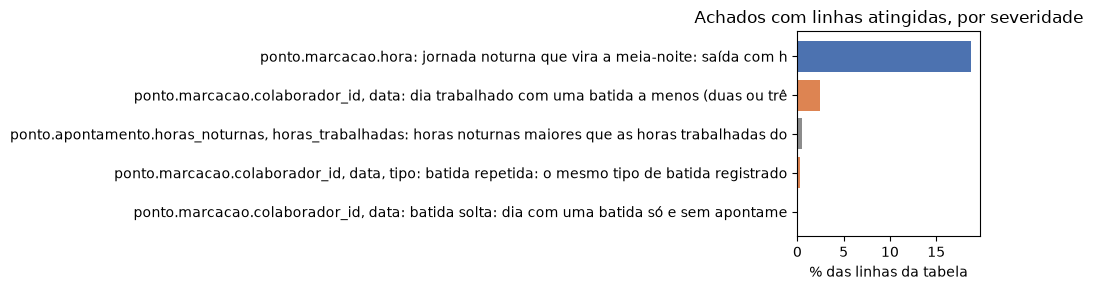

registro gravado em dados/auditoria/ponto.json


In [21]:
com_linhas = quadro[quadro["linhas"] > 0].sort_values("pct")
if len(com_linhas):
    fig, eixo = plt.subplots(figsize=(10, max(3, 0.4 * len(com_linhas))))
    cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C", "nenhuma": "#4C72B0"}
    eixo.barh(com_linhas["tabela"] + "." + com_linhas["coluna"] + ": " + com_linhas["achado"].str.slice(0, 50), com_linhas["pct"], color=[cores[s] for s in com_linhas["severidade"]])
    eixo.set_xlabel("% das linhas da tabela")
    eixo.set_title("Achados com linhas atingidas, por severidade")
    plt.tight_layout()
    plt.show()
caminho = registro.salvar(REFERENCIA.isoformat())
print(f"registro gravado em {caminho.relative_to(RAIZ)}")
con.close()

## Nota Técnica de fechamento

**O que foi examinado:** as 5 tabelas do domínio `ponto`, 41 colunas e 5,65 milhões de linhas vivas, na carga identificada na seção 2: tipo, completude e coerência entre status e horas, unicidade, domínios, as batidas do relógio (quantidade, repetição, ordem com o relógio deslocado), calendário e alocação, integridade referencial e as faixas.

**O veredicto: o apontamento é sólido e as batidas têm a sujeira esperada de um relógio de ponto.** Status, horas, alocação, contrato, escala e banco de horas contam a mesma história em 100% dos registros. A sujeira está na marcação: 26.890 dias com uma batida a menos (média), 6.368 dias com uma batida repetida (média), 292 batidas soltas (baixa), e 6.269 apontamentos com horas noturnas acima das trabalhadas cuja convenção o cliente precisa confirmar (baixa). O segundo defeito de ingestão do projeto (hora gravada como número) foi encontrado e corrigido aqui. Dois registros de severidade nenhuma: a jornada noturna que vira a meia-noite, que não é defeito mas exige regra própria em toda comparação de hora, e o apontamento íntegro contra alocação e calendário.

**Próximos passos:** `folha`, onde estas horas viram custo.